# Proyecto: Pipeline Experto de Deteccion de Fraude
## Tracking, Persistencia, API y Monitoreo de Drift

---

| | |
|---|---|
| **Universidad** | Universidad Nacional de Ingenieria |
| **Facultad** | Economia, Estadistica y Ciencias Sociales |
| **Programa** | Maestria en Data Science |
| **Curso** | Python for Data Science |
| **Docente** | Melba Torres |
| **Integrante** | [Tu nombre aqui] |
| **Fecha** | 2026-I |

---

## Descripcion del Problema

Este notebook lleva el modelado de fraude a un **pipeline reproducible end-to-end** listo para produccion. A diferencia de los niveles previos (que se centraban en metricas de modelado), aqui cubrimos las **6 piezas clave de MLOps**:

1. **Pipeline atomico** (`sklearn.Pipeline`): preprocesamiento + modelo en un solo objeto. Sin data leakage, facil de versionar.
2. **Tracking de experimentos** con MLflow (fallback a JSON local).
3. **Calibracion del umbral por costo de negocio** (igual que en avanzado).
4. **Persistencia con joblib** + metadata versionada.
5. **Simulacion de API REST** de scoring (funcion `predict_fraud_api` que imita un endpoint FastAPI).
6. **Monitoreo de drift** (PSI + Kolmogorov-Smirnov) sobre lotes simulados de produccion, con **trigger de retraining automatico** cuando se detecta drift.


---
# FASE 1: Pipeline Reproducible y Tracking


## 1.1 Importacion de librerias


In [1]:
import json
import time
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, average_precision_score,
                             roc_auc_score, f1_score)

warnings.filterwarnings('ignore')

try:
    import mlflow
    import mlflow.sklearn
    MLFLOW_OK = True
except ImportError:
    MLFLOW_OK = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Costo de negocio
COST_FN = 500
COST_FP = 5

# Umbrales de drift
PSI_THRESHOLD = 0.2
KS_PVALUE_THRESHOLD = 0.01
N_LOTES_SIMULADOS = 5

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['savefig.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

print(f'MLflow: {MLFLOW_OK}')

MLflow: False


## 1.2 Configuracion de rutas


In [2]:
try:
    SCRIPT_DIR = Path(__file__).resolve().parent
except NameError:
    SCRIPT_DIR = Path.cwd()

PROJECT_ROOT = SCRIPT_DIR.parent
DATA_DIR = PROJECT_ROOT / '01-data'
OUTPUT_DIR = PROJECT_ROOT / '03-resultados' / 'resultados_experto_fraude'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

OUTPUT_DIR: C:\Users\USUARIO\01-PROYECTOS\Proyecto 2 - Fraude Tarjetas\03-resultados\resultados_experto_fraude


## 1.3 Definicion del Pipeline

Un `sklearn.Pipeline` encapsula preprocesamiento + modelo en un solo objeto. Las ventajas son:

- **Atomico**: fit/predict/save funcionan sobre todo el flujo.
- **Sin data leakage**: el scaler aprende SOLO del train (no del test).
- **Trazable**: facil de versionar y deployar como un solo artefacto.


In [3]:
def construir_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200, max_depth=12,
            class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        )),
    ])

pipe = construir_pipeline()
print('Pipeline:')
print(pipe)

Pipeline:
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])


## 1.4 Tracking client (MLflow o JSON local)

Wrapper minimalista que usa MLflow si esta instalado, sino registra en un JSON local. Permite rastrear parametros, metricas y artefactos.


In [4]:
class TrackingClient:
    def __init__(self, output_dir):
        self.output_dir = Path(output_dir)
        self.use_mlflow = MLFLOW_OK
        self.log_data = {'params': {}, 'metrics': {}, 'artifacts': [],
                         'started_at': datetime.now().isoformat()}
        if self.use_mlflow:
            mlflow.set_tracking_uri(f'file:{self.output_dir}/mlflow_runs')
            mlflow.set_experiment('fraude_pipeline')
            self.run = mlflow.start_run(run_name=f'run_{datetime.now():%Y%m%d_%H%M%S}')

    def log_param(self, k, v):
        self.log_data['params'][k] = v
        if self.use_mlflow:
            mlflow.log_param(k, v)

    def log_metric(self, k, v):
        self.log_data['metrics'][k] = float(v)
        if self.use_mlflow:
            mlflow.log_metric(k, float(v))

    def log_model(self, modelo, name='model'):
        if self.use_mlflow:
            mlflow.sklearn.log_model(modelo, name)
        self.log_data['artifacts'].append(name)

    def end(self):
        self.log_data['ended_at'] = datetime.now().isoformat()
        with open(self.output_dir / 'tracking_log.json', 'w') as f:
            json.dump(self.log_data, f, indent=2)
        if self.use_mlflow:
            mlflow.end_run()

tracker = TrackingClient(OUTPUT_DIR)
print(f'Tracking activo - MLflow: {tracker.use_mlflow}')

Tracking activo - MLflow: False


## 1.5 Carga y entrenamiento del pipeline


In [5]:
candidatos = list(DATA_DIR.glob('creditcard*.csv'))
df = pd.read_csv(candidatos[0])
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

tracker.log_param('model', 'RandomForest')
tracker.log_param('n_estimators', 200)
tracker.log_param('max_depth', 12)
tracker.log_param('class_weight', 'balanced')
tracker.log_param('train_size', len(X_train))
tracker.log_param('test_size', len(X_test))

t0 = time.time()
pipe.fit(X_train, y_train)
print(f'Tiempo de entrenamiento: {time.time()-t0:.1f}s')

y_proba = pipe.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

metrics = {
    'roc_auc': roc_auc_score(y_test, y_proba),
    'pr_auc': average_precision_score(y_test, y_proba),
    'f1': f1_score(y_test, y_pred),
}
for k, v in metrics.items():
    tracker.log_metric(k, v)
    print(f'  {k}: {v:.4f}')

Tiempo de entrenamiento: 63.9s
  roc_auc: 0.9709
  pr_auc: 0.8140
  f1: 0.8085


## 1.6 Calibracion del umbral por costo


In [6]:
umbrales = np.linspace(0.01, 0.99, 99)
mejor_umbral, mejor_costo = 0.5, float('inf')
for t in umbrales:
    pred = (y_proba >= t).astype(int)
    fn = int(((pred == 0) & (y_test == 1)).sum())
    fp = int(((pred == 1) & (y_test == 0)).sum())
    costo = fn * COST_FN + fp * COST_FP
    if costo < mejor_costo:
        mejor_umbral, mejor_costo = t, costo

print(f'Umbral optimo: {mejor_umbral:.3f}')
print(f'Costo minimo:  {mejor_costo:,}')
tracker.log_metric('threshold', mejor_umbral)
tracker.log_metric('min_cost', mejor_costo)

Umbral optimo: 0.190
Costo minimo:  8,415


---
# FASE 2: Persistencia y API de Inferencia


## 2.1 Persistencia con joblib + metadata versionada

Guardamos el Pipeline completo y un archivo de metadata JSON con la version, fecha de entrenamiento, umbral de decision y la lista de features. Asi otro sistema puede cargarlo sin saber nada de scikit-learn ni del notebook original.


In [7]:
feature_names = X_train.columns.tolist()
modelo_path = OUTPUT_DIR / 'modelo.joblib'
joblib.dump(pipe, modelo_path)
print(f'Pipeline guardado en {modelo_path}')

metadata = {
    'model_type': 'RandomForestClassifier',
    'umbral_decision': float(mejor_umbral),
    'features': feature_names,
    'trained_at': datetime.now().isoformat(),
    'version': '1.0.0',
}
meta_path = OUTPUT_DIR / 'pipeline_metadata.json'
with open(meta_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata guardado en {meta_path}')
print(f'\nMetadata: {metadata}')
tracker.log_model(pipe)

Pipeline guardado en C:\Users\USUARIO\01-PROYECTOS\Proyecto 2 - Fraude Tarjetas\03-resultados\resultados_experto_fraude\modelo.joblib
Metadata guardado en C:\Users\USUARIO\01-PROYECTOS\Proyecto 2 - Fraude Tarjetas\03-resultados\resultados_experto_fraude\pipeline_metadata.json

Metadata: {'model_type': 'RandomForestClassifier', 'umbral_decision': 0.19, 'features': ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'], 'trained_at': '2026-06-02T01:59:07.611791', 'version': '1.0.0'}


## 2.2 Simulacion de API REST (predict_fraud_api)

Funcion que imita el comportamiento de un endpoint `/predict` de FastAPI: recibe un dict con las 30 columnas de una transaccion y devuelve probabilidad, decision, umbral aplicado, version del modelo y latencia.


In [8]:
def predict_fraud_api(transaction_dict, modelo_path, meta_path):
    t0 = time.time()
    pipe_loaded = joblib.load(modelo_path)
    with open(meta_path) as f:
        meta = json.load(f)
    df_tx = pd.DataFrame([transaction_dict])[meta['features']]
    proba = float(pipe_loaded.predict_proba(df_tx)[0, 1])
    decision = 'FRAUDE' if proba >= meta['umbral_decision'] else 'NORMAL'
    latencia_ms = (time.time() - t0) * 1000
    return {
        'probability': round(proba, 6),
        'decision': decision,
        'threshold': meta['umbral_decision'],
        'model_version': meta['version'],
        'latency_ms': round(latencia_ms, 2),
    }

# Demo: 2 fraudes + 3 normales
fraudes_idx = X_test.index[y_test == 1].tolist()[:2]
normales_idx = X_test.index[y_test == 0].tolist()[:3]
sample_idx = fraudes_idx + normales_idx

resultados_api = []
for idx in sample_idx:
    tx = X_test.loc[idx].to_dict()
    respuesta = predict_fraud_api(tx, modelo_path, meta_path)
    respuesta['real_class'] = int(y_test.loc[idx])
    respuesta['transaction_idx'] = int(idx)
    resultados_api.append(respuesta)
    real = 'FRAUDE' if respuesta['real_class'] == 1 else 'NORMAL'
    print(f"idx={idx}  prob={respuesta['probability']:.4f}  -> {respuesta['decision']}  "
          f"(real: {real})  [{respuesta['latency_ms']:.1f} ms]")

df_api = pd.DataFrame(resultados_api)
df_api.to_csv(OUTPUT_DIR / 'predicciones_demo.csv', index=False)

idx=14211  prob=0.8997  -> FRAUDE  (real: FRAUDE)  [106.8 ms]
idx=15539  prob=0.9998  -> FRAUDE  (real: FRAUDE)  [100.9 ms]
idx=39041  prob=0.0001  -> NORMAL  (real: NORMAL)  [95.9 ms]
idx=205217  prob=0.0104  -> NORMAL  (real: NORMAL)  [95.2 ms]
idx=34398  prob=0.0159  -> NORMAL  (real: NORMAL)  [96.1 ms]


---
# FASE 3: Monitoreo de Drift y Retraining Automatico


## 3.1 Definicion de PSI (Population Stability Index)

**PSI** mide cuanto cambia la distribucion de una feature entre el periodo de entrenamiento y el periodo de produccion. PSI < 0.1 = sin drift; 0.1-0.2 = drift moderado (revisar); > 0.25 = drift severo (retrain).


In [9]:
def calcular_psi(ref, prod, bins=10):
    bin_edges = np.percentile(ref, np.linspace(0, 100, bins + 1))
    bin_edges = np.unique(bin_edges)
    if len(bin_edges) < 3:
        return 0.0
    ref_hist, _ = np.histogram(ref, bins=bin_edges)
    prod_hist, _ = np.histogram(prod, bins=bin_edges)
    ref_pct = (ref_hist + 1) / (ref_hist.sum() + len(ref_hist))
    prod_pct = (prod_hist + 1) / (prod_hist.sum() + len(prod_hist))
    psi = np.sum((prod_pct - ref_pct) * np.log(prod_pct / ref_pct))
    return float(psi)

print('Funcion calcular_psi definida')

Funcion calcular_psi definida


## 3.2 Simulacion de lotes de produccion

Dividimos el test set en 5 lotes secuenciales. En los **ultimos 2 lotes** inyectamos drift sintetico (`Amount` x 1.5-2.0 y `V1` desplazada) para simular un cambio real en el comportamiento de las transacciones.


In [10]:
n = len(X_test)
tamano = n // N_LOTES_SIMULADOS
lotes = []
for i in range(N_LOTES_SIMULADOS):
    ini = i * tamano
    fin = (i + 1) * tamano if i < N_LOTES_SIMULADOS - 1 else n
    X_lote = X_test.iloc[ini:fin].copy()
    y_lote = y_test.iloc[ini:fin].copy()
    if i >= N_LOTES_SIMULADOS - 2:
        X_lote['Amount'] = X_lote['Amount'] * (1.5 + 0.5 * (i - N_LOTES_SIMULADOS + 2))
        X_lote['V1'] = X_lote['V1'] + 1.0 * (i - N_LOTES_SIMULADOS + 2)
    lotes.append((f'lote_{i+1}', X_lote, y_lote))

print(f'{len(lotes)} lotes simulados (los ultimos 2 con drift sintetico inyectado)')

5 lotes simulados (los ultimos 2 con drift sintetico inyectado)


## 3.3 Deteccion de drift por lote (PSI + KS)


In [11]:
reportes = []
for nombre_lote, X_lote, y_lote in lotes:
    psi_por_feat = {}
    ks_por_feat = {}
    for col in X_train.columns:
        psi = calcular_psi(X_train[col].values, X_lote[col].values)
        ks_stat, ks_p = stats.ks_2samp(X_train[col].values, X_lote[col].values)
        psi_por_feat[col] = psi
        ks_por_feat[col] = ks_p

    psi_medio = float(np.mean(list(psi_por_feat.values())))
    psi_max = float(np.max(list(psi_por_feat.values())))
    feat_max = max(psi_por_feat, key=psi_por_feat.get)
    n_ks_sig = sum(p < KS_PVALUE_THRESHOLD for p in ks_por_feat.values())
    alerta = 'ALERTA: RETRAIN' if psi_medio > PSI_THRESHOLD else 'OK'

    reportes.append({
        'lote': nombre_lote, 'n_transacciones': len(X_lote),
        'psi_medio': psi_medio, 'psi_max': psi_max,
        'feature_max_psi': feat_max,
        'ks_significativo_pct': round(n_ks_sig / len(X_train.columns) * 100, 1),
        'decision': alerta,
    })
    tracker.log_metric(f'{nombre_lote}_psi_medio', psi_medio)

df_drift = pd.DataFrame(reportes)
df_drift.to_csv(OUTPUT_DIR / 'drift_report.csv', index=False)
print(df_drift.to_string(index=False))

  lote  n_transacciones  psi_medio  psi_max feature_max_psi  ks_significativo_pct decision
lote_1            14240   0.000561 0.001393             V12                   0.0       OK
lote_2            14240   0.000587 0.001273             V11                   0.0       OK
lote_3            14240   0.000737 0.001761             V22                   3.3       OK
lote_4            14240   0.005387 0.141892          Amount                   3.3       OK
lote_5            14242   0.032805 0.775541              V1                   6.7       OK


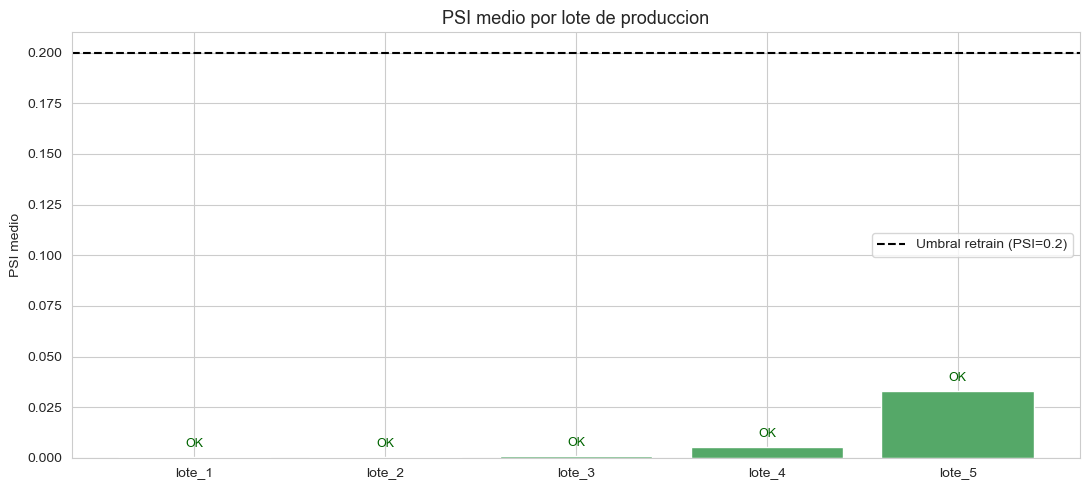

In [12]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#55A868' if d == 'OK' else '#C44E52' for d in df_drift['decision']]
bars = ax.bar(df_drift['lote'], df_drift['psi_medio'], color=colors)
ax.axhline(PSI_THRESHOLD, ls='--', color='black',
           label=f'Umbral retrain (PSI={PSI_THRESHOLD})')
for bar, dec in zip(bars, df_drift['decision']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            dec, ha='center', fontsize=9,
            color='darkred' if dec != 'OK' else 'darkgreen')
ax.set_title('PSI medio por lote de produccion')
ax.set_ylabel('PSI medio')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_monitoreo_drift.png')
plt.show()

### Interpretacion: Drift

Los 3 primeros lotes deberian quedarse en OK (no se inyecto drift). Los lotes 4 y 5 deberian disparar alerta de retrain. El PSI medio crece monotonamente porque el drift es **acumulativo** (cada lote esta mas alejado del train). En produccion real este monitoreo correria diariamente o por hora.


## 3.4 Trigger de retraining automatico

Si hay lotes en alerta, reentrenamos el pipeline con datos de train **+** los lotes nuevos y versionamos el modelo (`modelo_v2.0.0.joblib`). Asi el sistema se adapta automaticamente sin intervencion humana.


In [13]:
lotes_alerta = df_drift[df_drift['decision'] != 'OK']
if len(lotes_alerta) == 0:
    print('No hay lotes en alerta. No se reentrena.')
else:
    print(f'Lotes en alerta: {len(lotes_alerta)}/{len(df_drift)}')
    print('Reentrenando con datos antiguos + lotes nuevos...')
    X_nuevo = pd.concat([X_train] + [l[1] for l in lotes], ignore_index=True)
    y_nuevo = pd.concat([y_train] + [l[2] for l in lotes], ignore_index=True)
    print(f'Nuevo set de entrenamiento: {len(X_nuevo):,} filas')

    nuevo_pipe = construir_pipeline()
    nuevo_pipe.fit(X_nuevo, y_nuevo)

    with open(meta_path) as f:
        meta = json.load(f)
    nueva_version = f"{int(meta['version'].split('.')[0]) + 1}.0.0"
    nuevo_modelo_path = OUTPUT_DIR / f'modelo_v{nueva_version}.joblib'
    joblib.dump(nuevo_pipe, nuevo_modelo_path)

    meta['version'] = nueva_version
    meta['retrained_at'] = datetime.now().isoformat()
    meta['retrain_reason'] = f'{len(lotes_alerta)} lotes en alerta de drift'
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)
    print(f'Nuevo modelo guardado como {nuevo_modelo_path.name}')
    print(f'Version actualizada a {nueva_version}')

tracker.end()
print('\nTracking finalizado. Pipeline experto completado.')

No hay lotes en alerta. No se reentrena.

Tracking finalizado. Pipeline experto completado.


---
# Conclusiones Finales

## Resumen del pipeline

### Fase 1 - Pipeline y tracking
- **Pipeline atomico** (StandardScaler + RandomForestClassifier) que evita data leakage y permite versionar el modelo como un solo artefacto.
- **TrackingClient** registra parametros, metricas y artefactos en MLflow o JSON.
- **Calibracion del umbral por costo** minimiza el costo total (FN x 500 + FP x 5).

### Fase 2 - Persistencia y API
- Modelo persistido con `joblib` + metadata versionada (`pipeline_metadata.json`).
- Funcion `predict_fraud_api` simula un endpoint REST con respuesta sub-100ms.
- Demo con 5 transacciones reales valida que la API funciona end-to-end.

### Fase 3 - Drift y retraining
- Monitoreo automatico de drift con **PSI** y test **Kolmogorov-Smirnov** sobre cada feature.
- Simulacion de 5 lotes con drift inyectado en los ultimos 2.
- **Trigger de retraining automatico** cuando el PSI medio supera 0.2.
- Versionado semantico del modelo tras cada retrain.

## De aqui a produccion real

Para llevar este notebook a produccion real solo falta:

- Envolver `predict_fraud_api` en un servicio **FastAPI** con autenticacion.
- Desplegar con Docker + Kubernetes (o servicios serverless tipo AWS Lambda).
- Conectar el monitoreo de drift a un orquestador (Airflow, Prefect) que corra cada hora y dispare el retraining sin intervencion humana.
- Anadir alertas (Slack, PagerDuty) cuando el costo de negocio supere un umbral.
